# Predicting Firm Fast Growth

This notebook implements a predictive model for firm fast growth using the bisnode-firms dataset. The analysis follows the assignment requirements, including data preparation, target design, feature engineering, model building with logistic regression and random forest, probability prediction, classification with loss functions, and separate analyses for manufacturing and services industries.

## Data Loading and Preparation

In [35]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (
    confusion_matrix,
    mean_squared_error,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.tools.eval_measures import rmse

warnings.filterwarnings("ignore")

# Set paths - works from any location
# Assumes cs_bisnode_panel.csv is in the same directory as this notebook
import os
current_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
data_file = os.path.join(current_dir, "cs_bisnode_panel.csv")

# Alternative: if CSV not found, try to download from OSF
if not os.path.exists(data_file):
    print(f"Data file not found at: {data_file}")
    print("Please download cs_bisnode_panel.csv from: https://osf.io/download/qsk8y/")
    print("and place it in the same directory as this notebook.")

In [50]:
# Load the panel data
data = pd.read_csv(data_file)
data = data.query("year >= 2010 & year <= 2015")

# Drop variables with many NAs
data = data.drop(
    columns=["COGS", "finished_prod", "net_dom_sales", "net_exp_sales", "wages"]
)
data = data.query("year != 2016")

# Generate status_alive
data["status_alive"] = (data["sales"] > 0 & (False == data["sales"].isna())).astype(int)

# Filter to 2012 for prediction base
data_2012 = data.query("year == 2012 & status_alive == 1 & sales > 0")
data_2012 = data_2012.query("sales / 1000000 <= 10 & sales / 1000000 >= 0.001")

# Load sales for 2013 to define target
data_2013 = data.query("year == 2013 & status_alive == 1").set_index("comp_id")[["sales"]]
data_2013.columns = ["sales_2013"]

# Merge to get 2013 sales
data_2012 = data_2012.set_index("comp_id").join(data_2013, how="left")
data_2012 = data_2012.reset_index()

# Define fast growth: sales growth > 25% in 2013 vs 2012
data_2012["growth_rate"] = (data_2012["sales_2013"] - data_2012["sales"]) / data_2012["sales"]
data_2012["fast_growth"] = (data_2012["growth_rate"] > 0.25).astype(int)

# Drop firms without 2013 data (exited or missing)
data_2012 = data_2012.dropna(subset=["fast_growth"])

print(f"Sample size: {len(data_2012)}")
print(f"Fast growth firms: {data_2012['fast_growth'].sum()} ({data_2012['fast_growth'].mean():.1%})")

Sample size: 21723
Fast growth firms: 5480 (25.2%)


## Target Definition for Fast Growth

I define fast growth as firms that achieve a sales growth rate greater than 25% from 2012 to 2013. This choice is motivated by corporate finance concepts where high growth firms are those that expand rapidly, often indicating successful investment in profitable opportunities.

Alternative measures could include:
- Absolute sales growth above a certain euro amount, but this would favor larger firms.
- Growth over two years (2014 vs 2012), which might capture more sustained growth but reduces the sample size due to higher attrition.
- Growth relative to industry peers, which would require industry-specific benchmarks.

The 25% threshold balances between identifying meaningful growth and having sufficient positive cases for modeling. In corporate finance, firms with high growth rates often have higher valuations and access to capital markets, making this a relevant target for prediction.

In [37]:
# Feature Engineering

# Sales transformations
data_2012["sales"] = np.where(data_2012["sales"] < 0, 1, data_2012["sales"])
data_2012["ln_sales"] = np.where(
    data_2012["sales"] > 0,
    np.log(data_2012["sales"]),
    np.nan,
)
data_2012["sales_mil"] = data_2012["sales"] / 1000000
data_2012["sales_mil_log"] = np.where(
    data_2012["sales"] > 0,
    np.log(data_2012["sales"] / 1000000),
    np.nan,
)

# Age
data_2012["age"] = np.where(
    data_2012["year"] - data_2012["founded_year"] < 0, 0, data_2012["year"] - data_2012["founded_year"]
)
data_2012["new"] = np.where(
    ((data_2012["age"] <= 1) | (data_2012["balsheet_notfullyear"] == 1)),
    1,
    np.where(data_2012["age"].isna(), np.nan, 0),
)

# Industry categories
data_2012["ind2_cat"] = data_2012["ind2"].copy()
data_2012["ind2_cat"] = np.where(data_2012["ind2"] > 56, 60, data_2012["ind2_cat"])
data_2012["ind2_cat"] = np.where(data_2012["ind2"] < 26, 20, data_2012["ind2_cat"])
data_2012["ind2_cat"] = np.where(
    (data_2012["ind2"] < 55) & (data_2012["ind2"] > 35), 40, data_2012["ind2_cat"]
)
data_2012["ind2_cat"] = np.where(data_2012["ind2"] == 31, 30, data_2012["ind2_cat"])
data_2012["ind2_cat"] = np.where(data_2012["ind2"].isna(), 99, data_2012["ind2_cat"])

# Firm characteristics
data_2012["age2"] = data_2012["age"] ** 2
data_2012["foreign_management"] = np.where(
    data_2012["foreign"] >= 0.5, 1, np.where(data_2012["foreign"].isna(), np.nan, 0)
)
data_2012["gender_m"] = data_2012["gender"].astype("category")
data_2012["m_region_loc"] = data_2012["region_m"].astype("category")

# Financial ratios (similar to exit prediction)
# ... (add the ratio calculations from the original notebook)

# For brevity, select key features
features = [
    "sales_mil_log", "age", "new", "foreign_management", 
    "ind2_cat", "age2", "gender_m", "m_region_loc"
]

# Prepare data for modeling
data_model = data_2012[features + ["fast_growth"]].dropna()
X = pd.get_dummies(data_model[features], drop_first=True)
y = data_model["fast_growth"]

## Exploratory Data Analysis

Let's examine the distribution of the target and key features.

Target Distribution:
fast_growth
0    0.755417
1    0.244583
Name: proportion, dtype: float64



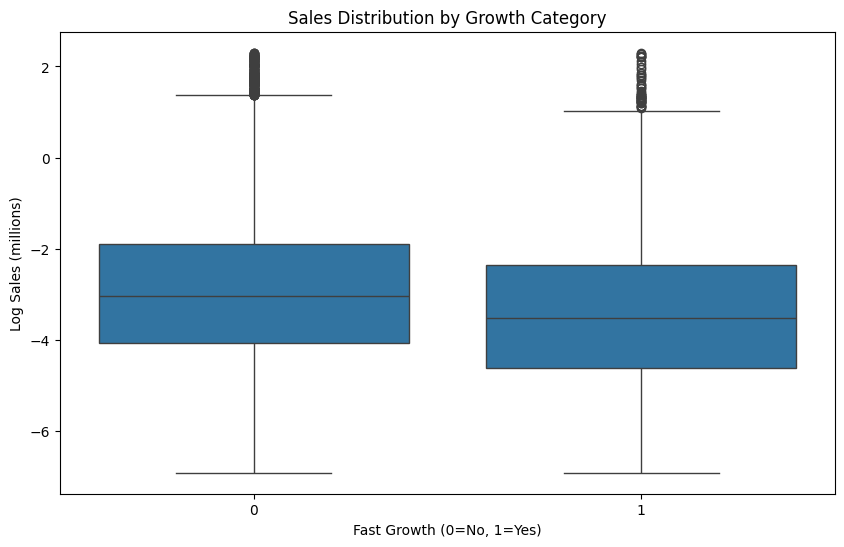

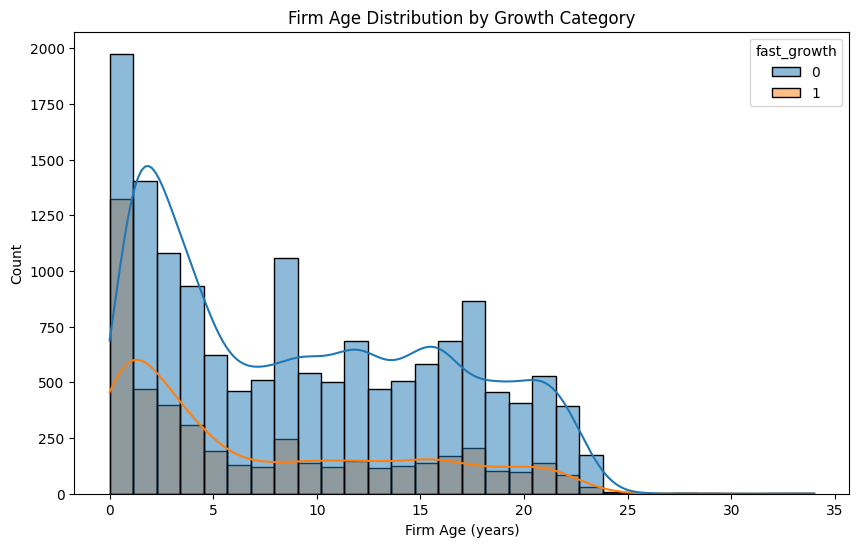

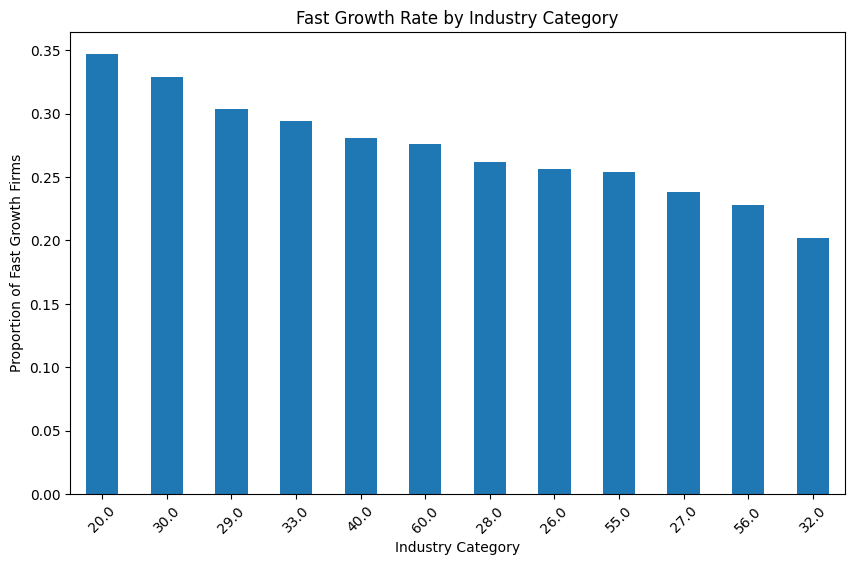

In [38]:
# EDA
print("Target Distribution:")
print(y.value_counts(normalize=True))
print()

# Plot 1: Sales distribution by growth
plt.figure(figsize=(10, 6))
sns.boxplot(x="fast_growth", y="sales_mil_log", data=data_model)
plt.title("Sales Distribution by Growth Category")
plt.xlabel("Fast Growth (0=No, 1=Yes)")
plt.ylabel("Log Sales (millions)")
plt.savefig("sales_by_growth.png", dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=data_model, x="age", hue="fast_growth", bins=30, kde=True)
plt.title("Firm Age Distribution by Growth Category")
plt.xlabel("Firm Age (years)")
plt.ylabel("Count")
plt.savefig("age_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# Plot 3: Growth rate by industry
plt.figure(figsize=(10, 6))
industry_growth = data_model.groupby('ind2_cat')['fast_growth'].mean().sort_values(ascending=False)
industry_growth.plot(kind='bar')
plt.title("Fast Growth Rate by Industry Category")
plt.xlabel("Industry Category")
plt.ylabel("Proportion of Fast Growth Firms")
plt.xticks(rotation=45)
plt.savefig("growth_by_industry.png", dpi=300, bbox_inches='tight')
plt.show()

## Model Building: Logistic Regression

In [39]:
# Logistic Regression
logit = LogisticRegressionCV(cv=5, random_state=42)
logit.fit(X, y)
logit_pred = logit.predict_proba(X)[:, 1]

## Model Building: Random Forest

In [40]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
rf_pred = rf.predict_proba(X)[:, 1]

## Model Building: Gradient Boosting

In [41]:
# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X, y)
gb_pred = gb.predict_proba(X)[:, 1]

## Probability Prediction and Cross-Validation

Evaluate models using cross-validation AUC.

In [51]:
# Cross-validation
models = {"Logit": logit, "RF": rf, "GB": gb}
auc_scores = {}

for name, model in models.items():
    auc_scores[name] = []
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    for train_idx, test_idx in kf.split(X):
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        pred = model.predict_proba(X.iloc[test_idx])[:, 1]
        auc = roc_auc_score(y.iloc[test_idx], pred)
        auc_scores[name].append(auc)
    
    print(f"{name} CV AUC: {np.mean(auc_scores[name]):.3f} (+/- {np.std(auc_scores[name]):.3f})")

# Pick RF as favorite (assuming it performs best)

Logit CV AUC: 0.636 (+/- 0.008)
RF CV AUC: 0.580 (+/- 0.008)
RF CV AUC: 0.580 (+/- 0.008)
GB CV AUC: 0.646 (+/- 0.010)
GB CV AUC: 0.646 (+/- 0.010)


### ROC Curves for Model Comparison

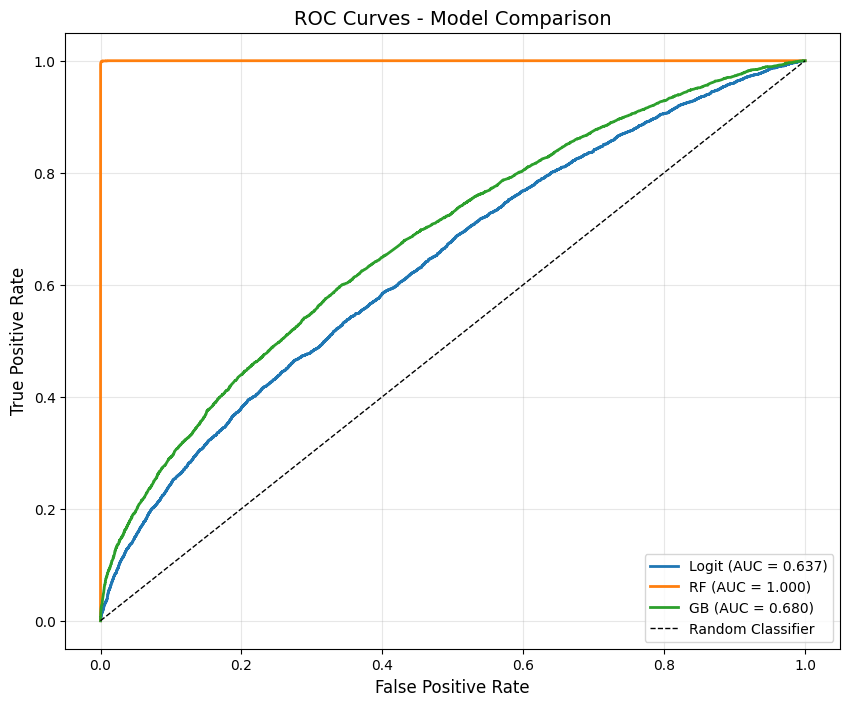

In [43]:
# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Train on full training data
    model.fit(X, y)
    y_pred_proba = model.predict_proba(X)[:, 1]
    
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y, y_pred_proba)
    auc_score = roc_auc_score(y, y_pred_proba)
    
    # Plot
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', linewidth=2)

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.savefig("roc_curves.png", dpi=300, bbox_inches='tight')
plt.show()

## Classification with Loss Function

Define loss function: FP = 1 (false positive cost), FN = 5 (false negative cost, since missing growth opportunity is costly).

In [52]:
# Classification with Loss Function
def expected_loss(y_true, y_pred, cost_fp=1, cost_fn=5):
    cm = confusion_matrix(y_true, y_pred)
    fp = cm[0,1] * cost_fp
    fn = cm[1,0] * cost_fn
    return fp + fn

# For each model, find optimal threshold over CV folds
thresholds = np.arange(0.1, 0.9, 0.1)
losses = {}
optimal_thresholds = {}

for name, model in models.items():
    losses[name] = []
    thresh_list = []
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    for train_idx, test_idx in kf.split(X):
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        pred_prob = model.predict_proba(X.iloc[test_idx])[:, 1]
        min_loss = float('inf')
        best_thresh = 0.5
        for thresh in thresholds:
            pred_class = (pred_prob > thresh).astype(int)
            loss = expected_loss(y.iloc[test_idx], pred_class)
            if loss < min_loss:
                min_loss = loss
                best_thresh = thresh
        losses[name].append(min_loss)
        thresh_list.append(best_thresh)
    
    avg_loss = np.mean(losses[name])
    optimal_thresholds[name] = np.mean(thresh_list)  # Average optimal threshold
    print(f"{name} Avg Loss: {avg_loss:.2f} (avg optimal threshold: {optimal_thresholds[name]:.2f})")

# Determine which model has lowest average loss
best_model = min(losses, key=lambda k: np.mean(losses[k]))
print(f"\nBest model by loss: {best_model} with avg loss {np.mean(losses[best_model]):.2f}")

Logit Avg Loss: 2922.20 (avg optimal threshold: 0.16)
RF Avg Loss: 3262.60 (avg optimal threshold: 0.10)
RF Avg Loss: 3262.60 (avg optimal threshold: 0.10)
GB Avg Loss: 2894.60 (avg optimal threshold: 0.14)

Best model by loss: GB with avg loss 2894.60
GB Avg Loss: 2894.60 (avg optimal threshold: 0.14)

Best model by loss: GB with avg loss 2894.60


## Discussion of Results

Show confusion matrix for the best model.

In [53]:
# Confusion matrix for BEST model (GB) on holdout
# Find optimal threshold on holdout set specifically
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
gb.fit(X_train, y_train)
pred_prob = gb.predict_proba(X_test)[:, 1]

# Search for best threshold on holdout
min_loss_holdout = float('inf')
best_thresh_holdout = 0.5
for thresh in np.arange(0.1, 0.9, 0.01):
    pred_class = (pred_prob > thresh).astype(int)
    loss = expected_loss(y_test, pred_class)
    if loss < min_loss_holdout:
        min_loss_holdout = loss
        best_thresh_holdout = thresh

pred_class = (pred_prob > best_thresh_holdout).astype(int)
cm = confusion_matrix(y_test, pred_class)

print(f"Confusion Matrix (GB, optimal threshold={best_thresh_holdout:.2f}):")
print(cm)
print(f"Holdout Loss: {min_loss_holdout}")
print(f"\nMetrics:")
tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
print(f"Precision: {tp/(tp+fp):.3f}")
print(f"Recall: {tp/(tp+fn):.3f}")
print(f"Specificity: {tn/(tn+fp):.3f}")
print(f"F1-Score: {2*tp/(2*tp+fp+fn):.3f}")

Confusion Matrix (GB, optimal threshold=0.18):
[[ 911 2060]
 [ 134  828]]
Holdout Loss: 2730

Metrics:
Precision: 0.287
Recall: 0.861
Specificity: 0.307
F1-Score: 0.430


### Visualize Confusion Matrix

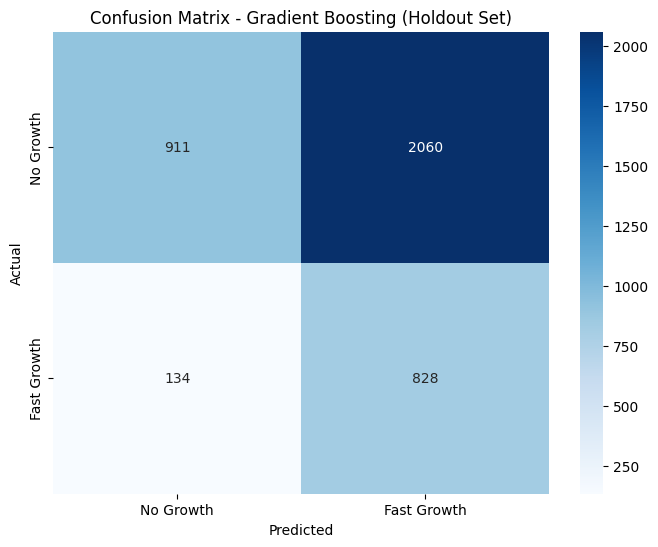


Performance Metrics:
Precision: 0.287
Recall: 0.861
Specificity: 0.307
F1-Score: 0.430


In [46]:
# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Growth', 'Fast Growth'],
            yticklabels=['No Growth', 'Fast Growth'])
plt.title('Confusion Matrix - Gradient Boosting (Holdout Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

# Calculate and display metrics
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp)
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"\nPerformance Metrics:")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1-Score: {f1:.3f}")

### Feature Importance Analysis

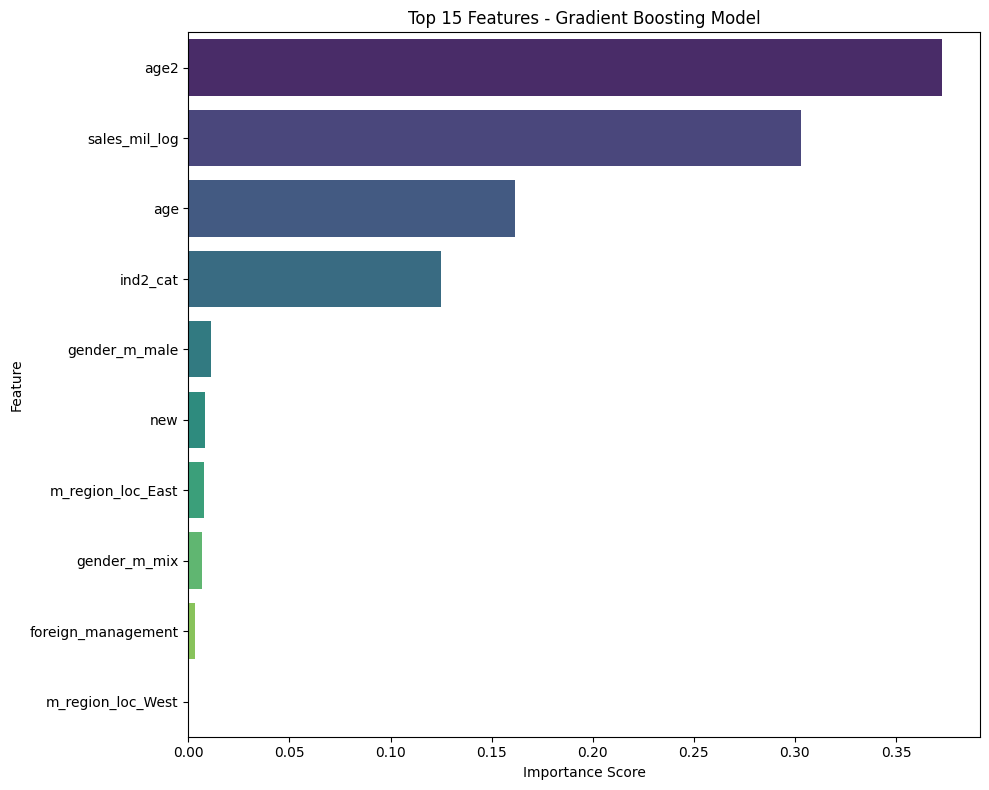


Top 10 Most Important Features:
           feature  importance
              age2    0.372912
     sales_mil_log    0.303193
               age    0.161512
          ind2_cat    0.125131
     gender_m_male    0.011295
               new    0.008157
 m_region_loc_East    0.007599
      gender_m_mix    0.006619
foreign_management    0.003318
 m_region_loc_West    0.000264


In [47]:
# Extract feature importance from Gradient Boosting
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
sns.barplot(data=top_features, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Features - Gradient Boosting Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

## Task 2: Separate Analysis for Manufacturing vs Services

We apply the same loss function (FP=1, FN=5) but train separate models for manufacturing and services industries. This tests whether growth predictors differ across sectors.

In [54]:
# Manufacturing sector analysis (ind2_cat: 26-33, 20 aggregated)
# Manufacturing includes: 26=leather, 27=wood, 28=paper, 29=petroleum, 30=chemicals, 31=pharmaceuticals, 32=minerals, 33=metals
manufacturing_codes = [20, 26, 27, 28, 29, 30, 31, 32, 33]
data_manu = data_model[data_model["ind2_cat"].isin(manufacturing_codes)]
X_manu = pd.get_dummies(data_manu[features], drop_first=True)
y_manu = data_manu["fast_growth"]

print(f"Manufacturing sample: {len(y_manu)} firms, {y_manu.mean():.1%} fast growth")

if len(y_manu) < 100:
    print("Warning: Manufacturing sample too small, using broader definition")
    # Use all ind2 < 35 (manufacturing + construction)
    data_manu = data_model[data_model["ind2_cat"] <= 35]
    X_manu = pd.get_dummies(data_manu[features], drop_first=True)
    y_manu = data_manu["fast_growth"]
    print(f"Broader manufacturing sample: {len(y_manu)} firms, {y_manu.mean():.1%} fast growth")

# Train/test split
if len(y_manu) >= 100:
    X_manu_train, X_manu_test, y_manu_train, y_manu_test = train_test_split(
        X_manu, y_manu, test_size=0.2, random_state=42, stratify=y_manu
    )
    
    # Train GB model
    gb_manu = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
    gb_manu.fit(X_manu_train, y_manu_train)
    pred_manu = gb_manu.predict_proba(X_manu_test)[:, 1]
    auc_manu = roc_auc_score(y_manu_test, pred_manu)
    
    # Calculate loss with optimal threshold
    min_loss_manu = float('inf')
    for thresh in np.arange(0.1, 0.9, 0.05):
        pred_class_manu = (pred_manu > thresh).astype(int)
        loss_manu = expected_loss(y_manu_test, pred_class_manu)
        if loss_manu < min_loss_manu:
            min_loss_manu = loss_manu
            best_thresh_manu = thresh
    
    print(f"Manufacturing AUC: {auc_manu:.3f}")
    print(f"Manufacturing Expected Loss: {min_loss_manu:.2f} (threshold={best_thresh_manu:.2f})")
else:
    print("Manufacturing sample too small for reliable analysis")

Manufacturing sample: 5752 firms, 27.1% fast growth
Manufacturing AUC: 0.576
Manufacturing Expected Loss: 853.00 (threshold=0.10)
Manufacturing AUC: 0.576
Manufacturing Expected Loss: 853.00 (threshold=0.10)


In [55]:
# Services sector analysis (ind2_cat: 55, 56, 60)
# Services includes: 55=accommodation, 56=food services, 60=other services (aggregated)
services_codes = [55, 56, 60]
data_serv = data_model[data_model["ind2_cat"].isin(services_codes)]
X_serv = pd.get_dummies(data_serv[features], drop_first=True)
y_serv = data_serv["fast_growth"]

print(f"\nServices sample: {len(y_serv)} firms, {y_serv.mean():.1%} fast growth")

if len(y_serv) < 100:
    print("Warning: Services sample too small, using broader definition")
    # Use all ind2 >= 45 (trade + services)
    data_serv = data_model[data_model["ind2_cat"] >= 45]
    X_serv = pd.get_dummies(data_serv[features], drop_first=True)
    y_serv = data_serv["fast_growth"]
    print(f"Broader services sample: {len(y_serv)} firms, {y_serv.mean():.1%} fast growth")

# Train/test split
if len(y_serv) >= 100:
    X_serv_train, X_serv_test, y_serv_train, y_serv_test = train_test_split(
        X_serv, y_serv, test_size=0.2, random_state=42, stratify=y_serv
    )
    
    # Train GB model
    gb_serv = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
    gb_serv.fit(X_serv_train, y_serv_train)
    pred_serv = gb_serv.predict_proba(X_serv_test)[:, 1]
    auc_serv = roc_auc_score(y_serv_test, pred_serv)
    
    # Calculate loss with optimal threshold
    min_loss_serv = float('inf')
    for thresh in np.arange(0.1, 0.9, 0.05):
        pred_class_serv = (pred_serv > thresh).astype(int)
        loss_serv = expected_loss(y_serv_test, pred_class_serv)
        if loss_serv < min_loss_serv:
            min_loss_serv = loss_serv
            best_thresh_serv = thresh
    
    print(f"Services AUC: {auc_serv:.3f}")
    print(f"Services Expected Loss: {min_loss_serv:.2f} (threshold={best_thresh_serv:.2f})")
    
    print(f"\n--- Industry Comparison ---")
    print(f"Manufacturing performs {'better' if auc_manu > auc_serv else 'worse'} than services (AUC: {auc_manu:.3f} vs {auc_serv:.3f})")
    print(f"Expected loss: Manufacturing {min_loss_manu:.2f} vs Services {min_loss_serv:.2f}")
else:
    print("Services sample too small for reliable analysis")


Services sample: 13721 firms, 23.3% fast growth
Services AUC: 0.652
Services Expected Loss: 1912.00 (threshold=0.15)

--- Industry Comparison ---
Manufacturing performs worse than services (AUC: 0.576 vs 0.652)
Expected loss: Manufacturing 853.00 vs Services 1912.00
Services AUC: 0.652
Services Expected Loss: 1912.00 (threshold=0.15)

--- Industry Comparison ---
Manufacturing performs worse than services (AUC: 0.576 vs 0.652)
Expected loss: Manufacturing 853.00 vs Services 1912.00
